In [1]:
!pip install networkx

In [2]:
import networkx as nx

print("Funcionou!")

Funcionou!


In [3]:
class User:
    def __init__(self, user_id, nome, interesses):
        self.user_id = user_id
        self.nome = nome
        self.interesses = interesses

    def get_info(self):
        return {
            "id": self.user_id,
            "nome": self.nome,
            "interesses": self.interesses
        }

In [4]:
user1 = User(1, "Paloma", ["fantasia", "romance"])
print(user1.get_info())

{'id': 1, 'nome': 'Paloma', 'interesses': ['fantasia', 'romance']}


In [5]:
import networkx as nx

class SocialNetwork:
    def __init__(self):
        self.graph = nx.Graph()

    def add_user(self, user):
        self.graph.add_node(user.user_id, data=user)
        print(f"Usuário {user.nome} adicionado.")

    def remove_user(self, user_id):
        self.graph.remove_node(user_id)
        print(f"Usuário {user_id} removido.")

    def connect_users(self, user1_id, user2_id):
        self.graph.add_edge(user1_id, user2_id)
        print(f"Usuários {user1_id} e {user2_id} conectados.")

    def disconnect_users(self, user1_id, user2_id):
        self.graph.remove_edge(user1_id, user2_id)
        print(f"Conexão entre {user1_id} e {user2_id} removida.")

In [6]:
# Criando usurios
user1 = User(1, "Paloma", ["fantasia", "romance"])
user2 = User(2, "João", ["fantasia"])
user3 = User(3, "Maria", ["terror"])

# Criando rede
rede = SocialNetwork()

# aqui eu adicioono usuarios
rede.add_user(user1)
rede.add_user(user2)
rede.add_user(user3)

# aqui conecta
rede.connect_users(1, 2)
rede.connect_users(1, 3)

Usuário Paloma adicionado.
Usuário João adicionado.
Usuário Maria adicionado.
Usuários 1 e 2 conectados.
Usuários 1 e 3 conectados.


In [11]:
import networkx as nx
from networkx.algorithms import community

class SocialNetwork:
    def __init__(self):
        self.graph = nx.Graph()

    def add_user(self, user):
        self.graph.add_node(user.user_id, data=user)
        print(f"Usuário {user.nome} adicionado.")

    def remove_user(self, user_id):
        self.graph.remove_node(user_id)
        print(f"Usuário {user_id} removido.")

    def connect_users(self, user1_id, user2_id):
        self.graph.add_edge(user1_id, user2_id)
        print(f"Usuários {user1_id} e {user2_id} conectados.")

    def disconnect_users(self, user1_id, user2_id):
        self.graph.remove_edge(user1_id, user2_id)
        print(f"Conexão entre {user1_id} e {user2_id} removida.")

    # adicionando comunidades
    def find_communities(self):
        communities = community.greedy_modularity_communities(self.graph)
        print("Comunidades encontradas:")
        for i, comm in enumerate(communities):
            print(f"Grupo {i+1}: {list(comm)}")
        return communities

    # centralidade
    def user_centralities(self, method='degree'):
        if method == 'degree':
            centrality = nx.degree_centrality(self.graph)
        elif method == 'betweenness':
            centrality = nx.betweenness_centrality(self.graph)
        else:
            print("Método não suportado")
            return

        print(f"Centralidade ({method}):")
        for user, value in centrality.items():
            print(f"Usuário {user}: {value:.2f}")
        return centrality

    # subgrafo
    def analyze_subgraph(self, user_ids):
        subgraph = self.graph.subgraph(user_ids)
        print("Subgrafo criado com usuários:", user_ids)
        print("Conexões:", list(subgraph.edges()))
        return subgraph

In [12]:
# Criando usuários
user1 = User(1, "Paloma", ["fantasia", "romance"])
user2 = User(2, "João", ["fantasia"])
user3 = User(3, "Maria", ["terror"])

# 🔥 CRIA A REDE DE NOVO
rede = SocialNetwork()

# Adicionando usuários
rede.add_user(user1)
rede.add_user(user2)
rede.add_user(user3)

# Conectando usuários
rede.connect_users(1, 2)
rede.connect_users(1, 3)

Usuário Paloma adicionado.
Usuário João adicionado.
Usuário Maria adicionado.
Usuários 1 e 2 conectados.
Usuários 1 e 3 conectados.


In [13]:
rede.find_communities()

Comunidades encontradas:
Grupo 1: [1, 2, 3]


[frozenset({1, 2, 3})]

In [14]:
import pandas as pd

dados = pd.DataFrame({
    "user_id": [1,2,3,4,5,6,7,8,9,10],
    "nome": ["Paloma","João","Maria","Ana","Carlos","Beatriz","Lucas","Fernanda","Rafael","Juliana"],
    "genero_favorito": ["fantasia","fantasia","terror","romance","romance","fantasia","terror","romance","fantasia","terror"],
    "livro": ["Harry Potter","Senhor dos Anéis","It","Orgulho e Preconceito","Como Eu Era Antes de Você",
              "Percy Jackson","Drácula","A Culpa é das Estrelas","Eragon","O Iluminado"],
    "avaliacao": [5,4,5,4,3,5,4,5,4,5]
})

dados

,user_id,nome,genero_favorito,livro,avaliacao
0,1,Paloma,fantasia,Harry Potter,5
1,2,João,fantasia,Senhor dos Anéis,4
2,3,Maria,terror,It,5
3,4,Ana,romance,Orgulho e Preconceito,4
4,5,Carlos,romance,Como Eu Era Antes de Você,3
5,6,Beatriz,fantasia,Percy Jackson,5
6,7,Lucas,terror,Drácula,4
7,8,Fernanda,romance,A Culpa é das Estrelas,5
8,9,Rafael,fantasia,Eragon,4
9,10,Juliana,terror,O Iluminado,5


In [15]:
dados.to_csv("dados_leitura.csv", index=False)

In [16]:
import networkx as nx

G = nx.Graph()

for _, row in dados.iterrows():
    G.add_node(row["user_id"], nome=row["nome"], genero=row["genero_favorito"])

for i, user1 in dados.iterrows():
    for j, user2 in dados.iterrows():
        if i != j:
            if user1["genero_favorito"] == user2["genero_favorito"]:
                G.add_edge(user1["user_id"], user2["user_id"])

print("Número de usuários:", G.number_of_nodes())
print("Número de conexões:", G.number_of_edges())

Número de usuários: 10
Número de conexões: 12


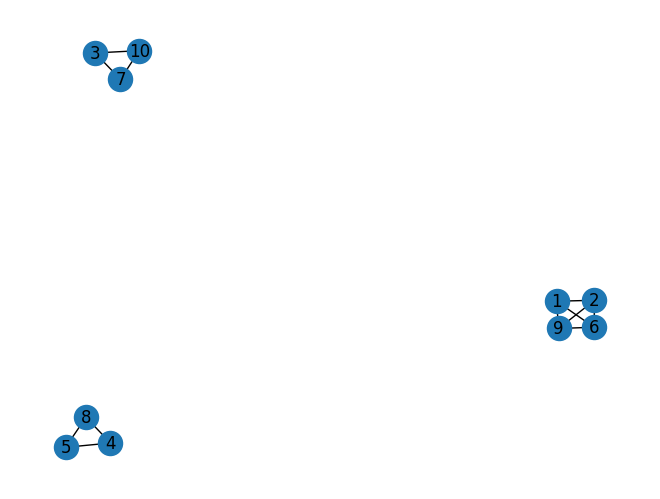

In [17]:
import matplotlib.pyplot as plt

nx.draw(G, with_labels=True)
plt.show()

In [18]:
from itertools import combinations

similaridade = []

for user1, user2 in combinations(dados["user_id"], 2):
    dados1 = dados[dados["user_id"] == user1]
    dados2 = dados[dados["user_id"] == user2]

    genero_igual = int(dados1["genero_favorito"].values[0] == dados2["genero_favorito"].values[0])
    diff_avaliacao = abs(dados1["avaliacao"].values[0] - dados2["avaliacao"].values[0])

    score = genero_igual * (1 / (1 + diff_avaliacao))

    similaridade.append((user1, user2, score))

similaridade[:10]

[(1, 2, np.float64(0.5)),
 (1, 3, np.float64(0.0)),
 (1, 4, np.float64(0.0)),
 (1, 5, np.float64(0.0)),
 (1, 6, np.float64(1.0)),
 (1, 7, np.float64(0.0)),
 (1, 8, np.float64(0.0)),
 (1, 9, np.float64(0.5)),
 (1, 10, np.float64(0.0)),
 (2, 3, np.float64(0.0))]

In [19]:
sim_df = pd.DataFrame(similaridade, columns=["user1", "user2", "score"])
sim_df.sort_values(by="score", ascending=False).head(10)

,user1,user2,score
4,1,6,1.0
23,3,10,1.0
15,2,9,1.0
0,1,2,0.5
7,1,9,0.5
20,3,7,0.5
37,6,9,0.5
41,7,10,0.5
27,4,8,0.5
12,2,6,0.5


In [20]:
def recomendar_livros(user_id, top_n=3):

    similares = sim_df[(sim_df["user1"] == user_id) | (sim_df["user2"] == user_id)]
    similares = similares.sort_values(by="score", ascending=False)

    usuarios_parecidos = []
    for _, row in similares.iterrows():
        if row["user1"] == user_id:
            usuarios_parecidos.append(row["user2"])
        else:
            usuarios_parecidos.append(row["user1"])

    usuarios_parecidos = usuarios_parecidos[:top_n]

    livros_usuario = set(dados[dados["user_id"] == user_id]["livro"])

    recomendacoes = set()

    for u in usuarios_parecidos:
        livros = set(dados[dados["user_id"] == u]["livro"])
        recomendacoes.update(livros)

    recomendacoes = recomendacoes - livros_usuario

    return list(recomendacoes)

In [ ]:
def recomendar_livros(user_id, top_n=3):

    similares = sim_df[(sim_df["user1"] == user_id) | (sim_df["user2"] == user_id)]
    similares = similares.sort_values(by="score", ascending=False)

    usuarios_parecidos = []
    for _, row in similares.iterrows():
        if row["user1"] == user_id:
            usuarios_parecidos.append(row["user2"])
        else:
            usuarios_parecidos.append(row["user1"])

    usuarios_parecidos = usuarios_parecidos[:top_n]

    livros_usuario = set(dados[dados["user_id"] == user_id]["livro"])

    recomendacoes = set()

    for u in usuarios_parecidos:
        livros = set(dados[dados["user_id"] == u]["livro"])
        recomendacoes.update(livros)

    recomendacoes = recomendacoes - livros_usuario

    return list(recomendacoes)

In [21]:
recomendar_livros(1)

['Percy Jackson', 'Eragon', 'Senhor dos Anéis']

In [22]:
dados["genero_favorito"].value_counts()

,count
genero_favorito,
fantasia,4
terror,3
romance,3


In [23]:
dados.groupby("genero_favorito")["avaliacao"].mean()

,avaliacao
genero_favorito,
fantasia,4.500000
romance,4.000000
terror,4.666667


In [24]:
centralidade = nx.degree_centrality(G)

sorted(centralidade.items(), key=lambda x: x[1], reverse=True)[:5]

[(1, 0.3333333333333333),
 (2, 0.3333333333333333),
 (6, 0.3333333333333333),
 (9, 0.3333333333333333),
 (3, 0.2222222222222222)]

In [25]:
sim_df.sort_values(by="score", ascending=False).head(5)

,user1,user2,score
4,1,6,1.0
23,3,10,1.0
15,2,9,1.0
0,1,2,0.5
7,1,9,0.5
